<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/MobilNet%20v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargar Base

In [1]:
from google.colab import userdata
import json

!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = {
    'username': userdata.get('KAGGLE_USER'),
    'key': userdata.get('KAGGLE_KEY')}
with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json


import kagglehub
path1 = kagglehub.dataset_download("leonardocaravaggio/ge-images")
path2 = kagglehub.dataset_download("leonardocaravaggio/ge-images2")
path3 = kagglehub.dataset_download("leonardocaravaggio/ge-images3")

100%|██████████| 13.3G/13.3G [03:08<00:00, 75.6MB/s]

Extracting files...


100%|██████████| 13.9G/13.9G [03:12<00:00, 77.9MB/s]

Extracting files...


100%|██████████| 336M/336M [00:02<00:00, 153MB/s]

Extracting files...


In [2]:
import os
import shutil

# Crear una carpeta de destino
dest_folder = "imagenes"
os.makedirs(dest_folder, exist_ok=True)

# Función para copiar imágenes a una sola carpeta
def mover_imagenes(origen, destino):
    for root, _, files in os.walk(origen):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                shutil.move(os.path.join(root, file), os.path.join(destino, file))

# Copiar imágenes de ambos datasets al mismo folder
mover_imagenes(path1, dest_folder)
mover_imagenes(path2, dest_folder)

print(f"Imágenes combinadas en la carpeta: {dest_folder}")

Imágenes combinadas en la carpeta: imagenes


In [3]:
import pandas as pd
ciudades=pd.read_csv("base.csv")

In [4]:
len(ciudades)

1095

In [ ]:
import numpy as np
ciudades['Desigualdad_1km']=np.nan
ciudades['Desigualdad_5km']=np.nan
ciudades['Desigualdad_10km']=np.nan
ciudades['Desigualdad_15km']=np.nan
#ciudades['Diferencia']=np.nan

#MobilNet v2

In [7]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import torch.nn.functional as F
import os

# Cargar MobileNetV2 hasta la capa 12
model = models.mobilenet_v2(pretrained=True)
model = torch.nn.Sequential(*list(model.features[:10]))
model.eval()

# Transformaciones de imagen
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Función para extraer características
def extract_index(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0)  # [1, 3, 224, 224]

    with torch.no_grad():
        features = model(image_tensor)  # Pasar por la red
        avg_pool = F.adaptive_avg_pool2d(features, (1, 1)).squeeze()  # [C]
        max_pool = F.adaptive_max_pool2d(features, (1, 1)).squeeze()  # [C]
        pooled_features = torch.cat((avg_pool, max_pool), dim=0)  # [2C]
        inequality_index = np.std(pooled_features.cpu().numpy())  # desigualdad


    return inequality_index

# Función para computar desigualdad a múltiples escalas
def compute_inequality(image_1km_path, image_5km_path, image_10km_path, image_15km_path):
    return {
        "Desigualdad_1km": extract_index(image_1km_path),
        "Desigualdad_5km": extract_index(image_5km_path),
        "Desigualdad_10km": extract_index(image_10km_path),
        "Desigualdad_15km": extract_index(image_15km_path),
    }

In [8]:
import os

lista_ciudades = [ "Desierto",  "Amazonas", "Oceano", "Santiago de Cuba", "Curitiba", "El Alto", "Montevideo", "Lo Barnechea", "Los Cedros", "La Cava", "Rocinha", "Retiro"]

for nombre in lista_ciudades:

    nombre_archivo = nombre.replace("/", ".").replace(":", "_").replace("'", "!")
    ruta_completa = os.path.join(path3, nombre_archivo)

    # Armar paths a las imágenes
    img_1k = ruta_completa + " - 1K.png"
    img_5k = ruta_completa + " - 5K.png"
    img_10k = ruta_completa + " - 10K.png"
    img_15k = ruta_completa + " - 15K.png"

    # Llamar a la función
    print(nombre, compute_inequality(img_1k, img_5k, img_10k, img_15k))


Desierto {'Desigualdad_1km': np.float32(0.52183473), 'Desigualdad_5km': np.float32(0.50487256), 'Desigualdad_10km': np.float32(0.52298063), 'Desigualdad_15km': np.float32(0.52162474)}
Amazonas {'Desigualdad_1km': np.float32(0.52817756), 'Desigualdad_5km': np.float32(0.4944517), 'Desigualdad_10km': np.float32(0.4733247), 'Desigualdad_15km': np.float32(0.66432285)}
Oceano {'Desigualdad_1km': np.float32(0.54565114), 'Desigualdad_5km': np.float32(0.5466991), 'Desigualdad_10km': np.float32(0.54537815), 'Desigualdad_15km': np.float32(0.53273565)}
Santiago de Cuba {'Desigualdad_1km': np.float32(0.67058116), 'Desigualdad_5km': np.float32(0.6258496), 'Desigualdad_10km': np.float32(0.623506), 'Desigualdad_15km': np.float32(0.6549402)}
Curitiba {'Desigualdad_1km': np.float32(0.67844087), 'Desigualdad_5km': np.float32(0.6008168), 'Desigualdad_10km': np.float32(0.5906677), 'Desigualdad_15km': np.float32(0.5978403)}
El Alto {'Desigualdad_1km': np.float32(0.66222197), 'Desigualdad_5km': np.float32(0.

In [ ]:
from tqdm import tqdm

# Procesamiento por ciudad
for i in tqdm(range(1095)):
    if pd.isna(ciudades.loc[i, "Desigualdad_1km"]):
        try:
            path='/content/'
            nombre_archivo = ciudades.City[i].replace("/", ".").replace(":", "_").replace("'", "!")
            ruta_completa = os.path.join(path, "imagenes", nombre_archivo)


            img_1k = ruta_completa + " - 1K.png"
            img_5k = ruta_completa + " - 5K.png"
            img_10k = ruta_completa + " - 10K.png"
            img_15k = ruta_completa + " - 15K.png"

            if not os.path.exists(img_1k):
                print(f"❌ No existe: {img_1k}")
                continue

            if not os.path.exists(img_5k):
                print(f"❌ No existe: {img_5k}")
                continue

            if not os.path.exists(img_10k):
                print(f"❌ No existe: {img_10k}")
                continue

            if not os.path.exists(img_15k):
                print(f"❌ No existe: {img_15k}")
                continue

            resultados = compute_inequality(img_10k, img_15k)
         #   ciudades.loc[i, "Desigualdad_1km"] = resultados["Desigualdad_1km"]
         #   ciudades.loc[i, "Desigualdad_5km"] = resultados["Desigualdad_5km"]
            ciudades.loc[i, "Desigualdad_10km"] = resultados["Desigualdad_10km"]
            ciudades.loc[i, "Desigualdad_15km"] = resultados["Desigualdad_15km"]
            #ciudades.loc[i, "Diferencia"] = resultados["Diferencia"]

        except Exception as e:
            print(f"⚠️ Error en {ciudades.City[i]}: {e}")

100%|██████████| 1095/1095 [08:00<00:00,  2.28it/s]


# Bajar la base con el indicador de desigualdad

In [ ]:
from scipy.stats import pearsonr

# Eliminar pares con NaN
x = ciudades["Desigualdad_10km"]
y = ciudades["P1ST"]
mask = x.notna() & y.notna()

# Calcular correlación de Pearson y p-value
r, p = pearsonr(x[mask], y[mask])

print(f"Coeficiente de Pearson: {r:.3f}")
print(f"Valor p: {p:.5f}")

Coeficiente de Pearson: -0.201
Valor p: 0.00000


In [ ]:
ciudades['Felicidad']=ciudades['P1ST']

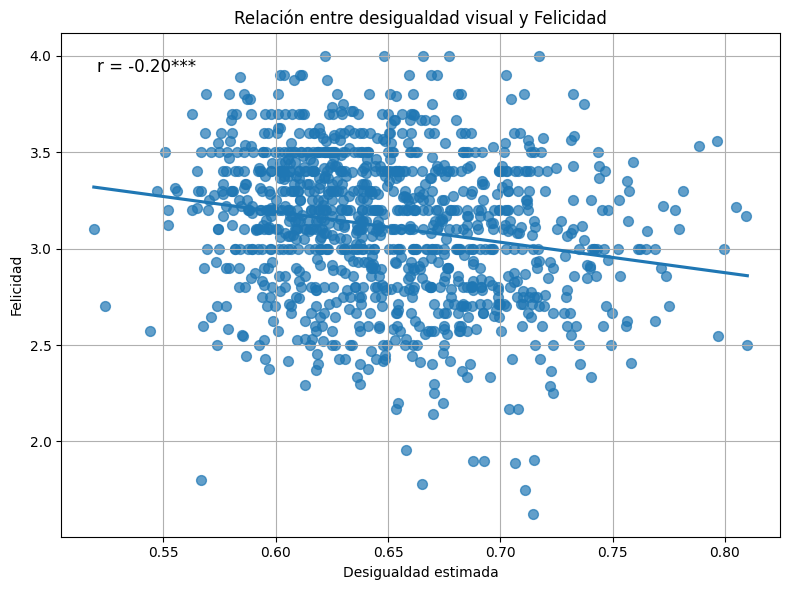

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Filtrar datos válidos
x = ciudades["Desigualdad_10km"]
y = ciudades["Felicidad"]
mask = x.notna() & y.notna()
x_valid = x[mask]
y_valid = y[mask]

# Calcular correlación
r, p = pearsonr(x_valid, y_valid)

# Determinar nivel de significancia
if p < 0.001:
    stars = "***"
elif p < 0.01:
    stars = "**"
elif p < 0.05:
    stars = "*"
else:
    stars = ""

# Crear gráfico
plt.figure(figsize=(8, 6))
sns.regplot(x=x_valid, y=y_valid, ci=None, scatter_kws={"s": 50, "alpha": 0.7})

# Anotar r y p
plt.text(0.05, 0.95, f"r = {r:.2f}{stars}", ha="left", va="top", transform=plt.gca().transAxes, fontsize=12)

plt.xlabel("Desigualdad estimada")
plt.ylabel("Felicidad")
plt.title("Relación entre desigualdad visual y Felicidad")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm
import numpy as np

# Definir variables
X = ciudades["Desigualdad_10km"].replace([np.inf, -np.inf], np.nan)
y = ciudades["P1ST"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   P1ST   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     68.83
Date:                Fri, 23 May 2025   Prob (F-statistic):           3.14e-16
Time:                        17:58:37   Log-Likelihood:                -454.57
No. Observations:                1095   AIC:                             913.1
Df Residuals:                    1093   BIC:                             923.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                4.1786      0.129  

In [ ]:
from google.colab import files
name="base_mobilv2.csv"
ciudades.to_csv(name)
files.download(name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>